# Task 4

MULTIMODAL HOUSING PRICE PREDICTION

[1] Creating sample dataset...
Created tabular dataset with 1000 samples
Features: ['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'garage', 'price']

[2] Simulating image data...
Created simulated image features with shape: (1000, 512)

[3] Preparing data for multimodal model...
Training samples: 800
Testing samples: 200

[4] Building multimodal model...

Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        768 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         65 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 206,273 (805.75 KB)

 Trainable params: 206,273 (805.75 KB)

 Non-trainable params: 0 (0.00 B)


[5] Training the multimodal model...
Training completed!

[6] Evaluating model performance...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step

Results:
Mean Absolute Error (MAE): $62,513.49
Root Mean Square Error (RMSE): $74,189.56

[7] Creating visualizations...


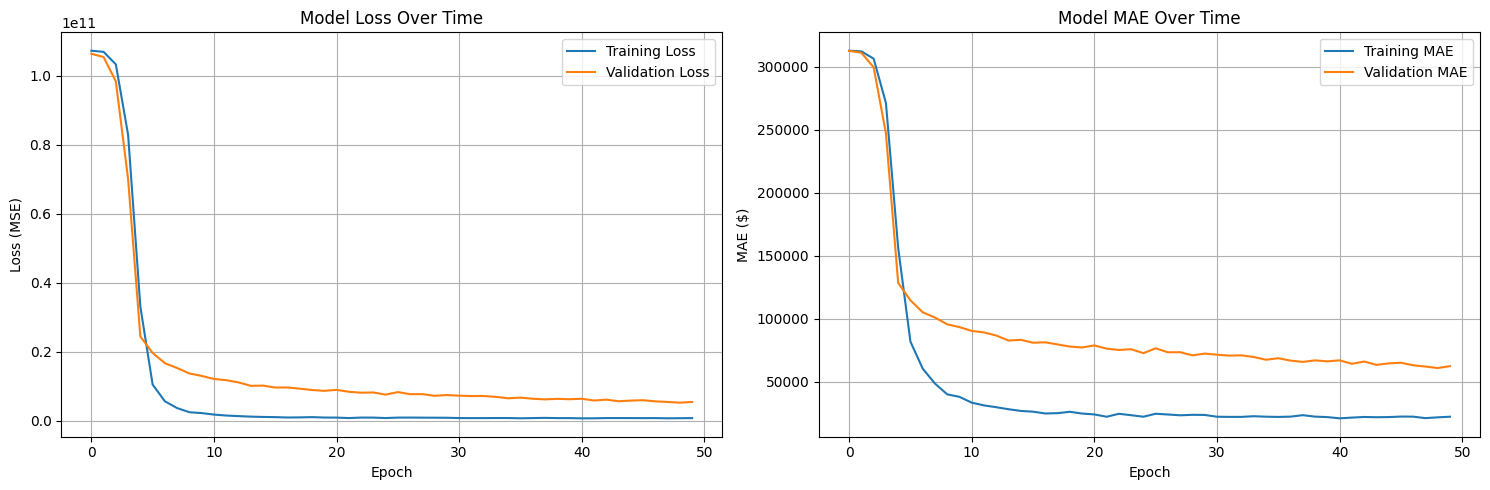

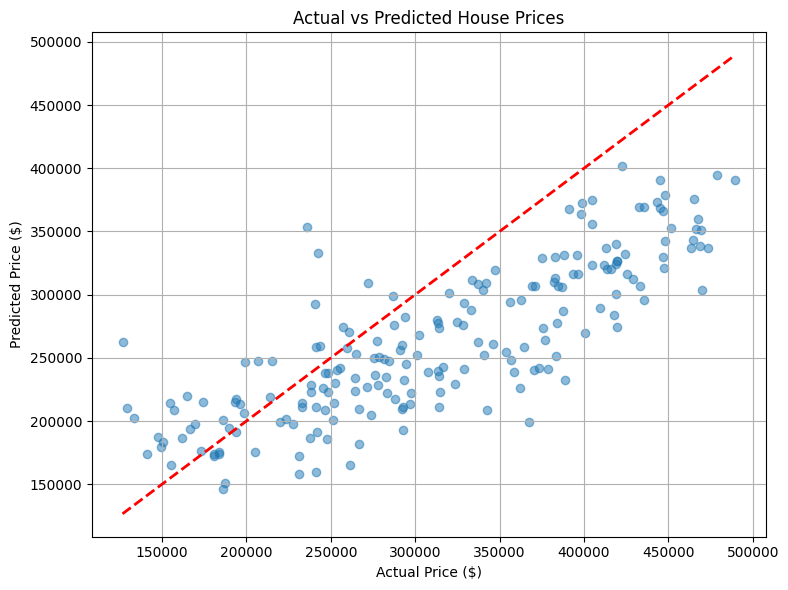


[8] Analyzing feature importance...

Tabular Feature Importance:
     feature  importance
0  area_sqft    0.972088
3  age_years    0.014136
1   bedrooms    0.006574
2  bathrooms    0.003995
4     garage    0.003206


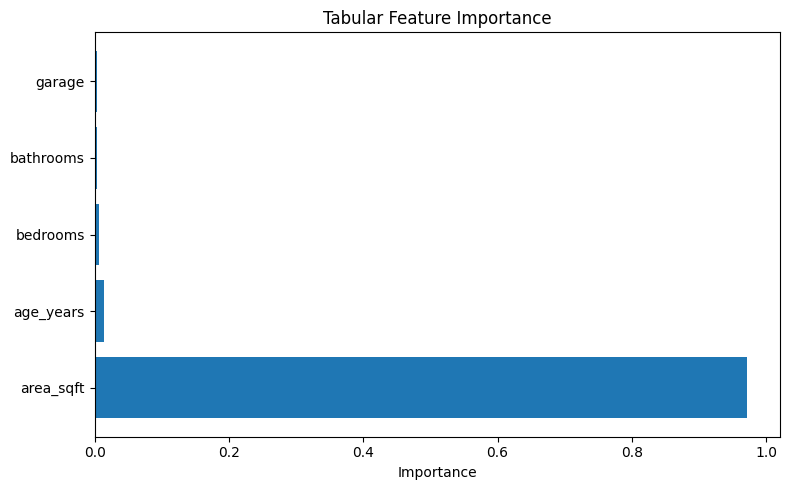


[9] Saving the model...
Model saved as 'multimodal_housing_model.h5'
Scaler saved as 'tabular_scaler.pkl'

[10] Making example predictions...

House 1:
  Actual Price: $346,988.59
  Predicted Price: $319,883.34
  Error: 7.81%

House 2:
  Actual Price: $384,003.68
  Predicted Price: $277,473.38
  Error: 27.74%

House 3:
  Actual Price: $346,388.10
  Predicted Price: $260,725.64
  Error: 24.73%

House 4:
  Actual Price: $238,351.42
  Predicted Price: $223,105.11
  Error: 6.40%

House 5:
  Actual Price: $418,033.13
  Predicted Price: $283,670.53
  Error: 32.14%

TASK COMPLETED SUCCESSFULLY!


In [1]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# we'll create a sample dataset
#we will load our actual housing dataset

print("=" * 60)
print("MULTIMODAL HOUSING PRICE PREDICTION")
print("=" * 60)

# Part 1: Create Sample Data
# ==========================

print("\n[1] Creating sample dataset...")

# Create sample tabular data
np.random.seed(42)
n_samples = 1000

tabular_data = pd.DataFrame({
    'area_sqft': np.random.randint(800, 3000, n_samples),
    'bedrooms': np.random.randint(1, 5, n_samples),
    'bathrooms': np.random.randint(1, 4, n_samples),
    'age_years': np.random.randint(0, 50, n_samples),
    'garage': np.random.choice([0, 1], n_samples),
    'price': np.random.randint(100000, 500000, n_samples)  # Target variable
})

# Add some correlation to make it realistic
tabular_data['price'] = (tabular_data['area_sqft'] * 150 +
                         tabular_data['bedrooms'] * 5000 +
                         tabular_data['bathrooms'] * 3000 +
                         tabular_data['garage'] * 10000 +
                         np.random.normal(0, 20000, n_samples))

print(f"Created tabular dataset with {n_samples} samples")
print(f"Features: {list(tabular_data.columns)}")

# For images, we'll simulate by creating dummy image features
# In reality, we would load actual house images

print("\n[2] Simulating image data...")

# Simulate image features (like what you'd get from CNN)
# In practice, you'd process actual images through a CNN
image_features = np.random.randn(n_samples, 512)  # 512-dim feature vector
print(f"Created simulated image features with shape: {image_features.shape}")

# Part 2: Prepare Data for Multimodal Model
# =========================================

print("\n[3] Preparing data for multimodal model...")

# Prepare tabular data
X_tabular = tabular_data.drop('price', axis=1)
y = tabular_data['price']

# Scale numerical features
scaler = StandardScaler()
X_tabular_scaled = scaler.fit_transform(X_tabular)

# Split the data
X_tab_train, X_tab_test, X_img_train, X_img_test, y_train, y_test = train_test_split(
    X_tabular_scaled, image_features, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_tab_train)}")
print(f"Testing samples: {len(X_tab_test)}")

# Part 3: Build Multimodal Model
# ===============================

print("\n[4] Building multimodal model...")

# Define input branches

# Branch 1: Tabular data input
tabular_input = layers.Input(shape=(X_tab_train.shape[1],), name='tabular_input')
tabular_branch = layers.Dense(128, activation='relu')(tabular_input)
tabular_branch = layers.Dropout(0.3)(tabular_branch)
tabular_branch = layers.Dense(64, activation='relu')(tabular_branch)

# Branch 2: Image features input
image_input = layers.Input(shape=(X_img_train.shape[1],), name='image_input')
image_branch = layers.Dense(256, activation='relu')(image_input)
image_branch = layers.Dropout(0.3)(image_branch)
image_branch = layers.Dense(128, activation='relu')(image_branch)
image_branch = layers.Dropout(0.3)(image_branch)

# Combine both branches
concatenated = layers.Concatenate()([tabular_branch, image_branch])

# Final regression layers
x = layers.Dense(128, activation='relu')(concatenated)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='linear', name='price_output')(x)

# Create the model
model = Model(inputs=[tabular_input, image_input], outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display model summary
print("\nModel Architecture:")
model.summary()

# Part 4: Train the Model
# =======================

print("\n[5] Training the multimodal model...")

# Train the model
history = model.fit(
    [X_tab_train, X_img_train],
    y_train,
    validation_data=([X_tab_test, X_img_test], y_test),
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Training completed!")

# Part 5: Evaluate the Model
# ===========================

print("\n[6] Evaluating model performance...")

# Make predictions
y_pred = model.predict([X_tab_test, X_img_test]).flatten()

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nResults:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${rmse:,.2f}")

# Part 6: Visualizations
# =======================

print("\n[7] Creating visualizations...")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss Over Time')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE Over Time')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE ($)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

# Part 7: Feature Importance Analysis
# ====================================

print("\n[8] Analyzing feature importance...")

# Simple feature importance for tabular data
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest on just tabular data for comparison
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_tab_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_tabular.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTabular Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Tabular Feature Importance')
plt.tight_layout()
plt.show()

# Part 8: Save the Model
# =======================

print("\n[9] Saving the model...")

# Save the multimodal model
model.save('multimodal_housing_model.h5')

# Save the scaler
import joblib
joblib.dump(scaler, 'tabular_scaler.pkl')

print("Model saved as 'multimodal_housing_model.h5'")
print("Scaler saved as 'tabular_scaler.pkl'")

# Part 9: Example Prediction
# ===========================

print("\n[10] Making example predictions...")

# Make a few example predictions
n_examples = 5
for i in range(n_examples):
    actual = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    predicted = y_pred[i]
    error_percentage = abs((actual - predicted) / actual) * 100

    print(f"\nHouse {i+1}:")
    print(f"  Actual Price: ${actual:,.2f}")
    print(f"  Predicted Price: ${predicted:,.2f}")
    print(f"  Error: {error_percentage:.2f}%")

print("\n" + "=" * 60)
print("TASK COMPLETED SUCCESSFULLY!")
print("=" * 60)

# Bonus: Function to process real images (if you have actual house images)
def process_house_image(image_path, target_size=(224, 224)):
    """
    Function to process a real house image for prediction
    """
    try:
        # Load and preprocess image
        img = Image.open(image_path)
        img = img.resize(target_size)
        img_array = np.array(img)

        # If grayscale, convert to RGB
        if len(img_array.shape) == 2:
            img_array = np.stack((img_array,) * 3, axis=-1)

        # Normalize
        img_array = img_array / 255.0

        # Load pre-trained CNN for feature extraction
        base_model = VGG16(weights='imagenet', include_top=False,
                          input_shape=(224, 224, 3))

        # Extract features
        img_array = np.expand_dims(img_array, axis=0)
        features = base_model.predict(img_array)
        features = features.flatten()[:512]  # Take first 512 features

        return features
    except Exception as e:
        print(f"Error processing image: {e}")
        return None